In [1]:
import pandas as pd

#para que aparezcan todas las columnas
pd.set_option('display.max_columns', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## **Abrimos y cambiamos nombres columnas en bank-additional**

In [2]:
datos_bancarios=pd.read_csv('../output/bank-additional_limpio_sin_nulos.csv')
datos_bancarios.sample(5)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,contact_month_num,contact_month,contact_year,age_range_cat,call_range_cat,quarter_cat,semester_cat
16924,47,technician,divorced,high_school,no,no,yes,cellular,417,5,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no,2019-03-01,35.147,-101.532,42e963df-d88c-4e53-9b63-a3304f2a9cf7,3.0,march,2019.0,45-54,5-15 min,1.0,1.0
17731,55,retired,married,high_school,no,yes,yes,cellular,394,3,999,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1,no,2018-05-12,32.103,-73.835,e4189309-fde8-4a69-adbf-80359df5010c,5.0,may,2018.0,55-64,5-15 min,2.0,1.0
6875,38,technician,married,basic_9y,no,no,no,telephone,514,3,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,no,2017-10-01,27.776,-68.725,b98fe23d-d0f4-4db8-bce3-d293e5788b63,10.0,october,2017.0,35-44,5-15 min,4.0,2.0
17349,39,admin,married,high_school,no,yes,yes,telephone,388,1,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no,2019-12-04,38.500,-108.243,43de4c2b-811a-4dfd-b7e9-56038f746a7b,12.0,december,2019.0,35-44,5-15 min,4.0,2.0
27042,29,entrepreneur,single,basic_4y,no,no,no,cellular,100,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,no,2015-02-20,47.188,-96.488,bc13a562-4a55-4f3f-a2fe-85ce01f5d0de,2.0,february,2015.0,25-34,1-5 min,1.0,1.0


In [3]:
datos_bancarios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                43000 non-null  int64  
 1   job                43000 non-null  object 
 2   marital            43000 non-null  object 
 3   education          43000 non-null  object 
 4   default            43000 non-null  object 
 5   housing            43000 non-null  object 
 6   loan               43000 non-null  object 
 7   contact            43000 non-null  object 
 8   duration           43000 non-null  int64  
 9   campaign           43000 non-null  int64  
 10  pdays              43000 non-null  int64  
 11  previous           43000 non-null  int64  
 12  poutcome           43000 non-null  object 
 13  emp.var.rate       43000 non-null  float64
 14  cons.price.idx     43000 non-null  float64
 15  cons.conf.idx      43000 non-null  float64
 16  euribor3m          430

In [4]:
datos_bancarios.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'y', 'date', 'latitude', 'longitude', 'id_',
       'contact_month_num', 'contact_month', 'contact_year', 'age_range_cat',
       'call_range_cat', 'quarter_cat', 'semester_cat'],
      dtype='object')

In [5]:
dic_columns = {
 "age": "age",
 "job": "occupation",
 "marital": "marital_status",
 "education": "education_level",
 "default": "credit_default",
 "housing": "housing_loan",
 "loan": "personal_loan",
 "contact": "contact_method",
 "duration": "last_contact_duration",
 "campaign": "campaign_contacts",
 "pdays": "days_since_last_contact",
 "previous": "previous_contacts",
 "poutcome": "previous_campaign_outcome",
 "emp.var.rate": "employment_variation_rate",
 "cons.price.idx": "consumer_price_index",
 "cons.conf.idx": "consumer_confidence_index",
 "euribor3m": "euribor_3m_rate",
 "nr.employed": "number_of_employees",
 "y": "subscription_status",
 "date": "interaction_date",
 "contact_month": "contact_month",
 "contact_year": "contact_year",
 "id_": "unique_id"
}

In [6]:
datos_bancarios_clientes= datos_bancarios.rename(columns= dic_columns)
datos_bancarios_clientes.sample(3)

,age,occupation,marital_status,education_level,credit_default,housing_loan,personal_loan,contact_method,last_contact_duration,campaign_contacts,days_since_last_contact,previous_contacts,previous_campaign_outcome,employment_variation_rate,consumer_price_index,consumer_confidence_index,euribor_3m_rate,number_of_employees,subscription_status,interaction_date,latitude,longitude,unique_id,contact_month_num,contact_month,contact_year,age_range_cat,call_range_cat,quarter_cat,semester_cat
22911,39,management,married,university_degree,unknown,yes,no,cellular,66,14,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no,2018-01-19,34.148,-106.370,a107688e-4bb9-433b-8087-6e5c9562de8b,1.0,january,2018.0,35-44,1-5 min,1.0,1.0
18117,38,housemaid,married,high_school,no,yes,no,cellular,335,5,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1,no,2018-05-21,39.171,-102.513,9370b639-c061-492e-aff8-795f0ceee634,5.0,may,2018.0,35-44,5-15 min,2.0,1.0
25086,40,unemployed,married,professional_course,no,no,no,telephone,129,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no,2017-09-29,41.618,-111.078,2d99ca4e-9468-4edc-a180-2b06da3735fa,9.0,september,2017.0,35-44,1-5 min,3.0,2.0


In [7]:
#cambio fecha de texto a fecha

datos_bancarios_clientes['interaction_date'] = pd.to_datetime(datos_bancarios_clientes['interaction_date'])

#Verificar que el cambio se realizó
print(datos_bancarios_clientes['interaction_date'].dtype)

datetime64[ns]


In [8]:
datos_bancarios_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   age                        43000 non-null  int64         
 1   occupation                 43000 non-null  object        
 2   marital_status             43000 non-null  object        
 3   education_level            43000 non-null  object        
 4   credit_default             43000 non-null  object        
 5   housing_loan               43000 non-null  object        
 6   personal_loan              43000 non-null  object        
 7   contact_method             43000 non-null  object        
 8   last_contact_duration      43000 non-null  int64         
 9   campaign_contacts          43000 non-null  int64         
 10  days_since_last_contact    43000 non-null  int64         
 11  previous_contacts          43000 non-null  int64         
 12  prev

In [9]:
#para ver las estadisticas principales, en formato T para hcerlo mas sencillo de ver
datos_bancarios_clientes.describe().T

,count,mean,min,25%,50%,75%,max,std
age,43000.0,39.860767,17.0,33.0,39.0,46.0,98.0,9.80194
last_contact_duration,43000.0,257.739279,0.0,102.0,179.0,319.0,4918.0,258.666033
campaign_contacts,43000.0,2.567233,1.0,1.0,2.0,3.0,56.0,2.772294
days_since_last_contact,43000.0,962.330953,0.0,999.0,999.0,999.0,999.0,187.260394
previous_contacts,43000.0,0.174023,0.0,0.0,0.0,0.0,7.0,0.497366
employment_variation_rate,43000.0,0.077128,-3.4,-1.8,1.1,1.4,1.4,1.573898
consumer_price_index,43000.0,93.574219,92.201,93.075,93.574219,93.994,94.767,0.576365
consumer_confidence_index,43000.0,-40.509049,-50.8,-42.7,-41.8,-36.4,-26.9,4.637186
euribor_3m_rate,43000.0,3.616521,0.634,1.466,4.076,4.959,5.045,1.538834
number_of_employees,43000.0,5166.852602,4963.6,5099.1,5191.0,5228.1,5228.1,72.411125


### **Abrimos y cambiamos nombres columnas en customer-details**

In [10]:
datos_adicionales=pd.read_csv('../output/customer_details_limpio_sin_nulos.csv')
datos_adicionales.sample(5)

,income,kidhome,teenhome,dt_customer,numwebvisitsmonth,id
1797,9455,2,1,2012-09-24,9,a44e70b7-4f3b-4d25-93bb-7bcb15653e38
14937,40567,0,1,2012-09-05,7,47503b1f-6bfb-45c9-bdd9-788d1ea6baeb
9500,41273,1,2,2012-12-12,29,bb7ea9eb-09d9-4fcd-9b20-82bd2f632e24
40654,12151,1,2,2014-09-09,28,1f821ba8-9a73-4125-a894-7af6d7151b4a
27360,115209,2,0,2013-08-16,8,485a237c-0046-4e66-a6fd-362d427607ad


In [11]:
datos_adicionales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43170 entries, 0 to 43169
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   income             43170 non-null  int64 
 1   kidhome            43170 non-null  int64 
 2   teenhome           43170 non-null  int64 
 3   dt_customer        43170 non-null  object
 4   numwebvisitsmonth  43170 non-null  int64 
 5   id                 43170 non-null  object
dtypes: int64(4), object(2)
memory usage: 2.0+ MB


In [12]:
datos_adicionales.columns

Index(['income', 'kidhome', 'teenhome', 'dt_customer', 'numwebvisitsmonth',
       'id'],
      dtype='object')

In [13]:
#institucion bancaria portuguesa, dinero en euros.
dic_columns = {
    "income": "annual_income_euros",
    "kidhome": "kids_at_home",
    "teenhome": "teens_at_home",
    "dt_customer": "enrollment_date",
    "numwebvisitsmonth": "monthly_web_visits",
    "id": "unique_id"
}

In [14]:
datos_adicionales_clientes= datos_adicionales.rename(columns= dic_columns)
datos_adicionales_clientes.sample(3)

,annual_income_euros,kids_at_home,teens_at_home,enrollment_date,monthly_web_visits,unique_id
38598,111199,0,1,2014-03-01,28,bc9ff18e-bd97-40e6-addc-79dfb5048363
16634,97002,2,2,2012-12-17,24,c3c51e25-bca6-435b-8945-de42a5e55bae
19223,70055,2,0,2012-09-17,19,2a73fb63-efa2-449c-82eb-9d53900b5405


In [15]:
#cambio fecha de texto a fecha

datos_adicionales_clientes['enrollment_date'] = pd.to_datetime(datos_adicionales_clientes['enrollment_date'])

#Verificar que el cambio se realizó
print(datos_adicionales_clientes['enrollment_date'].dtype)

datetime64[ns]


In [16]:
datos_adicionales_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43170 entries, 0 to 43169
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   annual_income_euros  43170 non-null  int64         
 1   kids_at_home         43170 non-null  int64         
 2   teens_at_home        43170 non-null  int64         
 3   enrollment_date      43170 non-null  datetime64[ns]
 4   monthly_web_visits   43170 non-null  int64         
 5   unique_id            43170 non-null  object        
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 2.0+ MB


In [17]:
datos_adicionales_clientes.describe().T

,count,mean,min,25%,50%,75%,max,std
annual_income_euros,43170.0,93227.389622,5841.0,49608.0,93009.5,136740.5,180802.0,50498.181989
kids_at_home,43170.0,1.004749,0.0,0.0,1.0,2.0,2.0,0.815996
teens_at_home,43170.0,0.998633,0.0,0.0,1.0,2.0,2.0,0.816008
enrollment_date,43170,2013-05-11 22:09:47.407922176,2012-01-01 00:00:00,2012-07-16 00:00:00,2013-03-01 00:00:00,2014-03-28 00:00:00,2014-12-31 00:00:00,NaN
monthly_web_visits,43170.0,16.59129,1.0,9.0,17.0,25.0,32.0,9.241769


### **Unimos ambos documentos**

In [18]:
#utilizamos la columna de id que está en ambos documentos

datos_unidos_clientes= pd.merge(datos_bancarios_clientes, datos_adicionales_clientes, on= 'unique_id', how='left')

In [19]:
datos_unidos_clientes.head(3)

,age,occupation,marital_status,education_level,credit_default,housing_loan,personal_loan,contact_method,last_contact_duration,campaign_contacts,days_since_last_contact,previous_contacts,previous_campaign_outcome,employment_variation_rate,consumer_price_index,consumer_confidence_index,euribor_3m_rate,number_of_employees,subscription_status,interaction_date,latitude,longitude,unique_id,contact_month_num,contact_month,contact_year,age_range_cat,call_range_cat,quarter_cat,semester_cat,annual_income_euros,kids_at_home,teens_at_home,enrollment_date,monthly_web_visits
0,39,housemaid,married,basic_4y,no,no,no,telephone,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857000,5191.0,no,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,8.0,august,2019.0,35-44,1-5 min,3.0,2.0,161770,1,0,2012-04-04,29
1,57,services,married,high_school,unknown,no,no,telephone,149,1,999,0,nonexistent,1.1,93.994,-36.4,3.616521,5191.0,no,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,9.0,september,2016.0,55-64,1-5 min,3.0,2.0,85477,1,1,2012-12-30,7
2,37,services,married,high_school,no,yes,no,telephone,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857000,5191.0,no,2019-02-15,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,2.0,february,2019.0,35-44,1-5 min,1.0,1.0,147233,1,1,2012-02-02,5


### Primeras conclusiones de estadisticas principales:

-**campaign contacts**:  de media, se han realizado casi 3 contactos con cliente durante esta campaña (media 2.5), con unn máximo de 56 contactos y un mínimo de 1.

-**previous_contacts** no ha habido pradcticamente contactos previos con los datos_bancarios_graficos_clientes (media 0.17), con minimos de 0 y maximos de 7

-**duration**: Media de interaccion con el cliente de 257 segundos (257/60: media de 4,2 minutos). Maxima duración de 1 hora 36 minutos, Mínimo de 0 segundos, entendemos que no han respondido


### **Análisis de la campaña**:

##### **informacion relevante demografica de los clientes de la campaña**
    - franja de edad ('age_range_cat')
    - trabajos ('occupation')
    - nivel educativo ('education_level')
    - niños y adolescentes en casa ('kids_at_home', 'teens_at_home' )

##### **informacion bancaria relevante de los clientes de la campaña**

    - incumplimiento de pagos ('credit_default')
    - hipoteca ('housing_loan')
    - otros prestamos ('personal_loan')
    - año de inicio como cliente del banco ('enrollment_date')

##### **informacion relevante sobre la campaña llevada a cabo**
    - metodo de contacto ('contact_method')
    - franja de duracion ultimo contacto ('call_range_cat')
    - contactos con cliente antes de la campaña ('previous_contacts')
    - resultado de la campaña anterior ('previous_campaign_outcome')
    - suscripcion a un producto del banco ('subscription_status')
    - mes de contacto ('contact_month_num')
    - año de contacto ('contact_year')
    - visitas mensuales a la web de la empresa ('monthly_web_visits')

## Información demográfica

- **edad**:la franja de edad mas frecuente es de 35 a 44 con casi 17.5k clientes, seguida de 25 a 34 (12.5k). La media de edad es de 40 años.
- **trabajos**: los trabajos mas frecuentes son de administrativos (10.8k, 25%) y obreros (9.6k, 22%), seguidos por técnicos (7k, 16%)
- **nivel educativo**: la mayoria cuenta con educacion universitaria (12.7k), seguida de nivel de educación secundaria (9.9k)
- **niños en casa**: no hay gran diferencia entre niños en casa, teniendo como máximo 2 y estando distribuidos de forma similar alrededor de un 33% del total de clientes
- **adolescentes en casa**: sucede similar a los niños, no hay diferencias significativas.

### **Edad**

In [20]:
datos_unidos_clientes['age'].mean()

np.float64(39.86076744186047)

In [21]:
orden_edades= ['17-24', '25-34', '35-44', '45-54', '55-64', '65+']

<Axes: xlabel='age_range_cat', ylabel='count'>

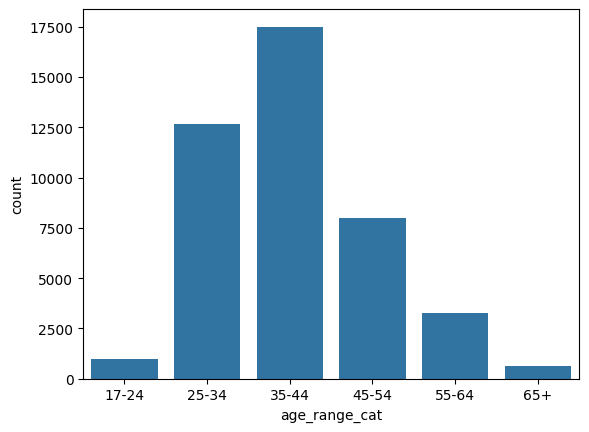

In [22]:
sns.countplot(data=datos_unidos_clientes,  x='age_range_cat', order=orden_edades)

### **Empleo**

<Axes: xlabel='count', ylabel='occupation'>

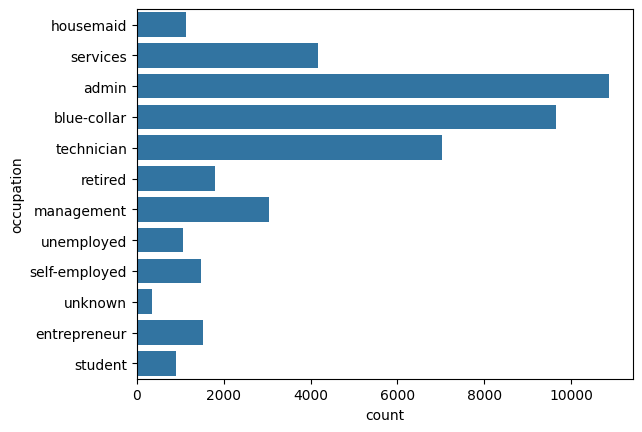

In [23]:
sns.countplot(datos_unidos_clientes['occupation'])

In [24]:
#para analisis escrito, miramos las cifras exactas y los porcentajes
conteo_trabajos = datos_unidos_clientes['occupation'].value_counts()
print(conteo_trabajos)

occupation
admin            10873
blue-collar       9654
technician        7026
services          4162
management        3050
retired           1790
entrepreneur      1522
self-employed     1489
housemaid         1123
unemployed        1063
student            903
unknown            345
Name: count, dtype: int64


In [25]:
conteo_trabajos_porcentaje = datos_unidos_clientes['occupation'].value_counts(normalize=True) *100
print(conteo_trabajos_porcentaje)

occupation
admin            25.286047
blue-collar      22.451163
technician       16.339535
services          9.679070
management        7.093023
retired           4.162791
entrepreneur      3.539535
self-employed     3.462791
housemaid         2.611628
unemployed        2.472093
student           2.100000
unknown           0.802326
Name: proportion, dtype: float64


### **Nivel Educativo**

<Axes: xlabel='count', ylabel='education_level'>

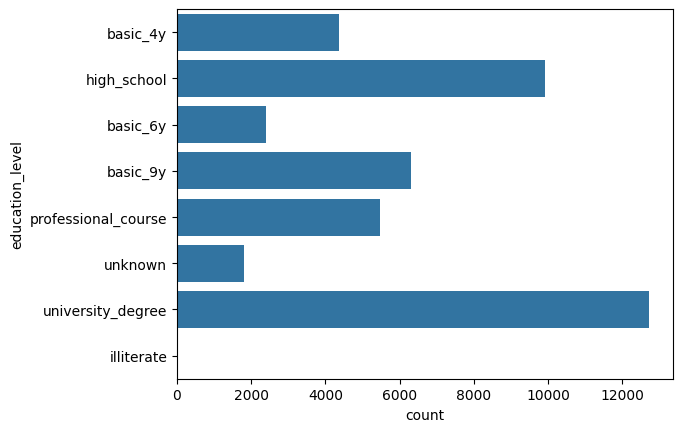

In [26]:
sns.countplot(datos_unidos_clientes['education_level'])

In [27]:
#para analisis escrito, miramos las cifras exactas y los porcentajes
conteo_educacion = datos_unidos_clientes['education_level'].value_counts()
print(conteo_educacion)

education_level
university_degree      12722
high_school             9925
basic_9y                6309
professional_course     5477
basic_4y                4356
basic_6y                2386
unknown                 1807
illiterate                18
Name: count, dtype: int64


In [28]:
conteo_educacion_porcentaje= datos_unidos_clientes['education_level'].value_counts(normalize=True) *100
print(conteo_educacion_porcentaje)

education_level
university_degree      29.586047
high_school            23.081395
basic_9y               14.672093
professional_course    12.737209
basic_4y               10.130233
basic_6y                5.548837
unknown                 4.202326
illiterate              0.041860
Name: proportion, dtype: float64


## Hijos en casa: niños y adolescentes

In [51]:
#cambio a int

datos_unidos_clientes['kids_at_home'] = datos_unidos_clientes['kids_at_home'].astype(int)
datos_unidos_clientes['kids_at_home'].dtype

dtype('int64')

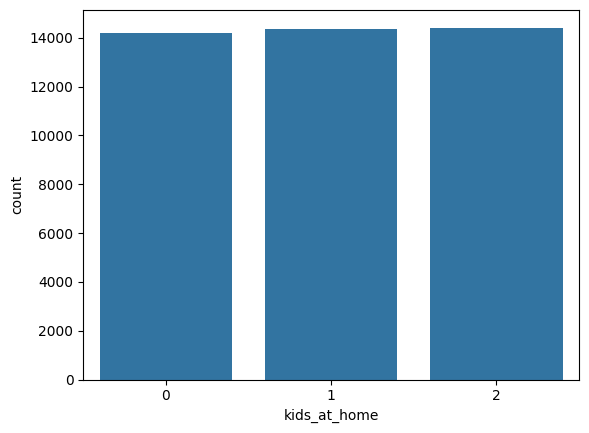

In [56]:
sns.countplot(x='kids_at_home', data=datos_unidos_clientes)
plt.show()

In [57]:
#para analisis escrito, miramos las cifras exactas y los porcentajes
conteo_niños = datos_unidos_clientes['kids_at_home'].value_counts()
print(conteo_niños)

kids_at_home
2    14416
1    14374
0    14210
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribución de niños en casa')

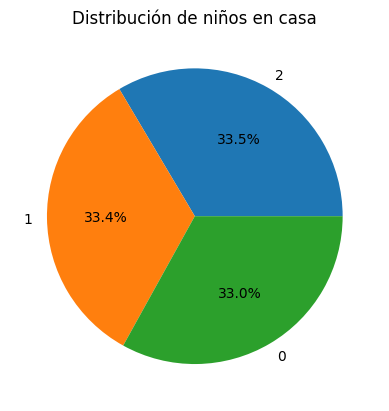

In [66]:
#probamos con grafico redondo, más clara la distribución similar

plt.pie(conteo_niños, labels=conteo_niños.index, autopct='%1.1f%%')
plt.title('Distribución de niños en casa')

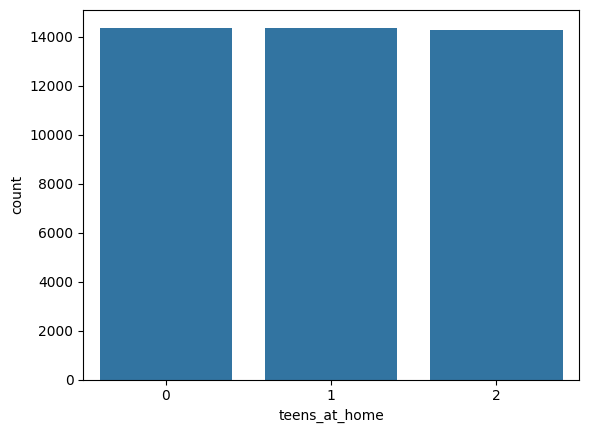

In [67]:
sns.countplot(x='teens_at_home', data=datos_unidos_clientes)
plt.show()

In [69]:
#para analisis escrito, miramos las cifras exactas y los porcentajes
conteo_adolescentes = datos_unidos_clientes['teens_at_home'].value_counts()
print(conteo_adolescentes)

teens_at_home
1    14370
0    14345
2    14285
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribución de adolescentes en casa')

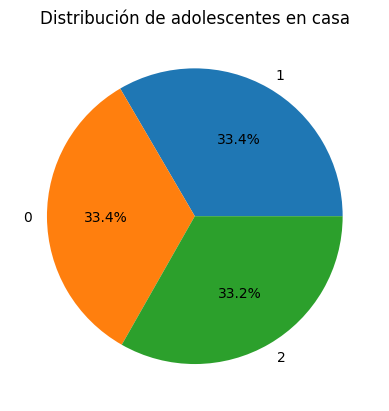

In [71]:
#probamos con grafico redondo, más clara la distribución similar

plt.pie(conteo_adolescentes, labels=conteo_adolescentes.index, autopct='%1.1f%%')
plt.title('Distribución de adolescentes en casa')

## Informacion bancaria
-**incumplimiento de pagos**  la mayoria de clientes no tienen inclumplimientos de pagos con un 79,1%  
-**hipoteca** : poca diferencia, con un 52.3% con hipoteca y un 45.3% sin   
-**otros prestamos** : la mayoria de clientes no tienen otro tipo de prestamos (84.5%)  
-**año de inicio como cliente del banco**: la mayoria de los clientes del banco se unieron a este en 2012, con una caida de mas del 50% en 2013.  

#### **incumplimiento pagos**

In [73]:
conteo_credito = datos_unidos_clientes['credit_default'].value_counts()
print(conteo_credito)

credit_default
no         34016
unknown     8981
yes            3
Name: count, dtype: int64


Text(0.5, 1.0, 'Incumplimientos de pagos')

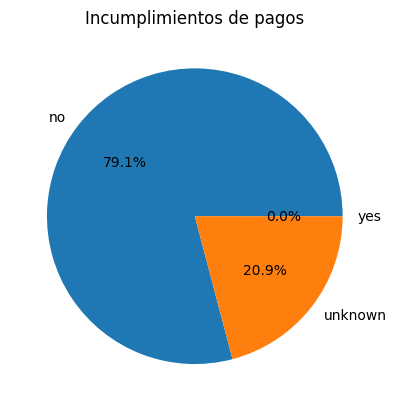

In [74]:
plt.pie(conteo_credito, labels=conteo_credito.index, autopct='%1.1f%%')
plt.title('Incumplimientos de pagos')

#### **hipoteca**

In [76]:
conteo_hipotecas = datos_unidos_clientes['housing_loan'].value_counts()
print(conteo_hipotecas)

housing_loan
yes        22498
no         19476
unknown     1026
Name: count, dtype: int64


Text(0.5, 1.0, '¿Tienen hipoteca?')

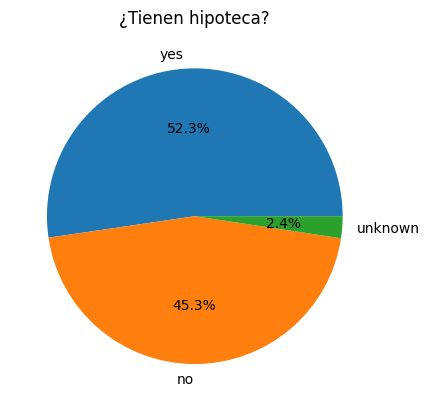

In [77]:
plt.pie(conteo_hipotecas, labels=conteo_hipotecas.index, autopct='%1.1f%%')
plt.title('¿Tienen hipoteca?')

In [ ]:
conteo_credito = datos_unidos_clientes['credit_default'].value_counts()
print(conteo_credito)

#### **otros prestamos**

In [78]:
conteo_otros_prestamos = datos_unidos_clientes['personal_loan'].value_counts()
print(conteo_otros_prestamos)

personal_loan
no     36468
yes     6532
Name: count, dtype: int64


Text(0.5, 1.0, '¿Tienen otros prestamos?')

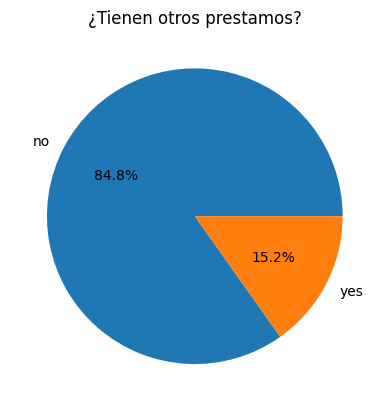

In [79]:
plt.pie(conteo_otros_prestamos, labels=conteo_otros_prestamos.index, autopct='%1.1f%%')
plt.title('¿Tienen otros prestamos?')

In [84]:
#cambio fecha de texto a fecha

datos_unidos_clientes['enrollment_date'] = pd.to_datetime(datos_unidos_clientes['enrollment_date'] )

#Verificar que el cambio se realizó
print(datos_unidos_clientes['enrollment_date'] .dtype)

datetime64[ns]


In [90]:
año_cliente = datos_unidos_clientes['enrollment_date'].dt.year

0        2012
1        2012
2        2012
3        2012
4        2012
         ... 
42995    2014
42996    2014
42997    2014
42998    2014
42999    2014
Name: enrollment_date, Length: 43000, dtype: int32


In [91]:
conteo_año_cliente = año_cliente.value_counts()
print(conteo_año_cliente)

enrollment_date
2012    20018
2014    14064
2013     8918
Name: count, dtype: int64


In [ ]:
#para el displot crear una columna de mes de cliente
datos_unidos_clientes['enrollment_month_num']= datos_unidos_clientes['enrollment_date'].dt.month
datos_unidos_clientes.sample(2)

,age,occupation,marital_status,education_level,credit_default,housing_loan,personal_loan,contact_method,last_contact_duration,campaign_contacts,days_since_last_contact,previous_contacts,previous_campaign_outcome,employment_variation_rate,consumer_price_index,consumer_confidence_index,euribor_3m_rate,number_of_employees,subscription_status,interaction_date,latitude,longitude,unique_id,contact_month_num,contact_month,contact_year,age_range_cat,call_range_cat,quarter_cat,semester_cat,annual_income_euros,kids_at_home,teens_at_home,enrollment_date,monthly_web_visits,enrollment_month_num
3868,47,management,married,basic_4y,unknown,no,no,telephone,268,6,999,0,nonexistent,1.1,93.994,-36.4,3.616521,5191.0,no,2016-09-24,48.929,-69.865,544b6677-bb92-4095-ac80-7ed716ac0926,9.0,september,2016.0,45-54,1-5 min,3.0,2.0,162049,2,0,2012-05-30,1,5
3691,29,management,single,university_degree,no,yes,no,telephone,257,2,999,0,nonexistent,1.1,93.994,-36.4,4.859000,5191.0,no,2016-05-23,47.916,-69.691,4dcbd8bc-7d0c-4694-b649-ca70c4d6e47a,5.0,may,2016.0,25-34,1-5 min,2.0,1.0,143912,2,2,2012-11-03,19,11


In [100]:
#para el displot crear una columna de año de cliente
datos_unidos_clientes['enrollment_year_num']= datos_unidos_clientes['enrollment_date'].dt.year
datos_unidos_clientes.sample(2)

,age,occupation,marital_status,education_level,credit_default,housing_loan,personal_loan,contact_method,last_contact_duration,campaign_contacts,days_since_last_contact,previous_contacts,previous_campaign_outcome,employment_variation_rate,consumer_price_index,consumer_confidence_index,euribor_3m_rate,number_of_employees,subscription_status,interaction_date,latitude,longitude,unique_id,contact_month_num,contact_month,contact_year,age_range_cat,call_range_cat,quarter_cat,semester_cat,annual_income_euros,kids_at_home,teens_at_home,enrollment_date,monthly_web_visits,enrollment_month_num,enrollment_year_num
3376,59,admin,married,high_school,unknown,yes,yes,telephone,118,4,999,0,nonexistent,1.1,93.994,-36.4,3.616521,5191.0,no,2018-03-27,37.117,-77.861,5e92505a-6c98-4631-bd03-e8fb690bdd48,3.0,march,2018.0,55-64,1-5 min,1.0,1.0,95360,1,1,2012-12-27,12,12,2012
8532,56,housemaid,married,basic_4y,no,no,no,telephone,204,1,999,0,nonexistent,1.4,94.465,-41.8,4.864000,5228.1,no,2017-09-06,24.558,-68.498,7ffbc9a4-a206-416d-bac2-33fa2e9d382d,9.0,september,2017.0,55-64,1-5 min,3.0,2.0,115750,0,0,2012-03-28,4,3,2012


In [104]:
#comprobamos los años para definir manualmente en el grafico para que no salgan decimales
datos_unidos_clientes['enrollment_year_num'].unique()


array([2012, 2013, 2014], dtype=int32)

In [105]:
orden_años_enrollment= [2012, 2013, 2014]

<Axes: xlabel='enrollment_year_num', ylabel='count'>

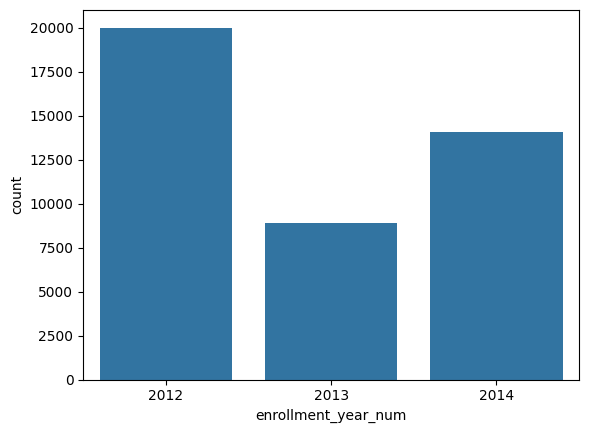

In [107]:
sns.countplot(data=datos_unidos_clientes, x='enrollment_year_num', order=orden_años_enrollment)


## Información sobre la campaña
- **franja de duracion ultimo contacto ('call_range_cat')**: la mayoria de las llamadas duran entre 1 y 15 minutos, con la franja mas frecuente siendo de 1 a 5 min  
- **contactos con cliente antes de la campaña ('previous_contacts'**): el 86% de los clientes nunca fueron contactados anteriormente 
- **resultado de la campaña anterior ('previous_campaign_outcome')**: al no ser contactados el mismo porcentaje se aplica a resultado inexistente (86%). Del resto de clientes que sí fueron contactados, 4.4k fue un fallo mientras que funcionó con 134k clientes.  
- **suscripcion a un producto del banco ('subscription_status')**: Un 88% de los clientes no se ha suscrito a un producto del banco 
- **año de contacto ('contact_year')**: No hay gran diferencia entre los años de contacto, con alrededor de 8.5k cada año desde 2015 a 2019
- visitas mensuales a la web de la empresa ('monthly_web_visits') 
- **forma de contacto** ('contact_method'): El método de contacto mas utilizado es pod teléwfono movil  (+25k)

In [110]:
orden_tiempo_llamadas= ['0 min','0-1 min', '1-5 min', '5-15 min', '15-30 min', '30-45 min', '+45 min']

### **Franja duración ultimo contacto**

<Axes: xlabel='call_range_cat', ylabel='count'>

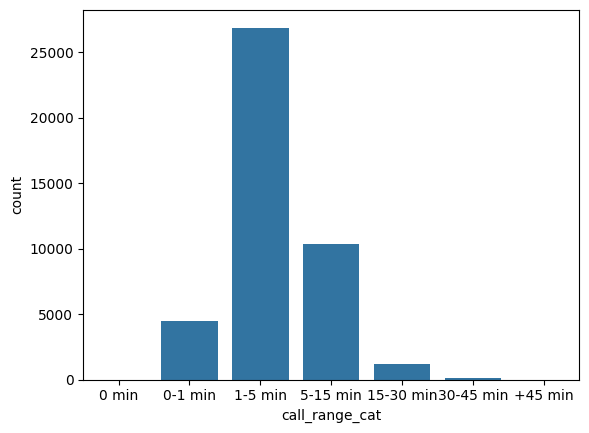

In [112]:
sns.countplot(data=datos_unidos_clientes,  x='call_range_cat', order=orden_tiempo_llamadas)

### **Contactos previos a la llamada**

<Axes: xlabel='previous_contacts', ylabel='count'>

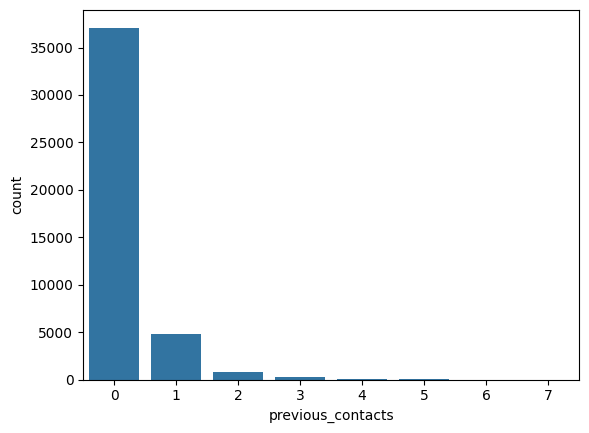

In [114]:
sns.countplot(data=datos_unidos_clientes,  x='previous_contacts')

In [115]:
conteo_contactos_porcentaje = datos_unidos_clientes['previous_contacts'].value_counts(normalize=True) *100
print(conteo_contactos_porcentaje)

previous_contacts
0    86.286047
1    11.111628
2     1.827907
3     0.539535
4     0.174419
5     0.046512
6     0.011628
7     0.002326
Name: proportion, dtype: float64


### **Resultado campaña anterior**

<Axes: xlabel='previous_campaign_outcome', ylabel='count'>

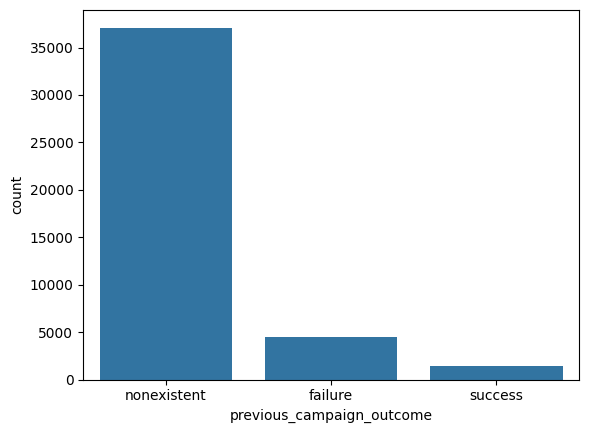

In [117]:
sns.countplot(data=datos_unidos_clientes,  x='previous_campaign_outcome')

In [121]:
conteo_campaña_anterior = datos_unidos_clientes['previous_campaign_outcome'].value_counts()
conteo_campaña_anterior

previous_campaign_outcome
nonexistent    37103
failure         4461
success         1436
Name: count, dtype: int64

In [119]:
conteo_campaña_anterior_porcentaje = datos_unidos_clientes['previous_campaign_outcome'].value_counts(normalize=True) *100
print(conteo_campaña_anterior_porcentaje)

previous_campaign_outcome
nonexistent    86.286047
failure        10.374419
success         3.339535
Name: proportion, dtype: float64


### **Suscripción a un producto**

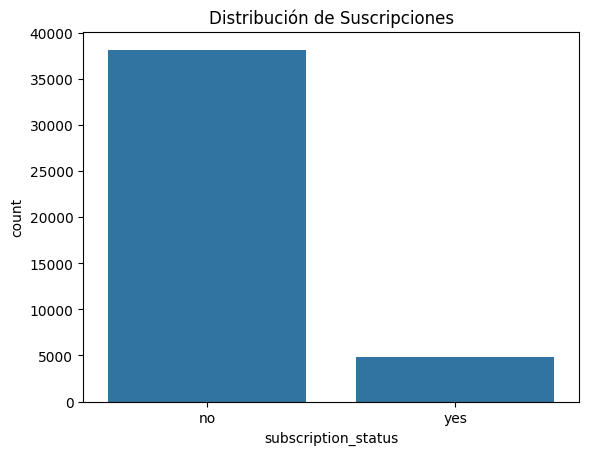

In [125]:
sns.countplot(x='subscription_status', data=datos_unidos_clientes)
plt.title('Distribución de Suscripciones')
plt.show()

In [126]:
conteo_suscripcion_porcentaje = datos_unidos_clientes['subscription_status'].value_counts(normalize=True) *100
print(conteo_suscripcion_porcentaje)

subscription_status
no     88.734884
yes    11.265116
Name: proportion, dtype: float64


### **Forma de contacto**

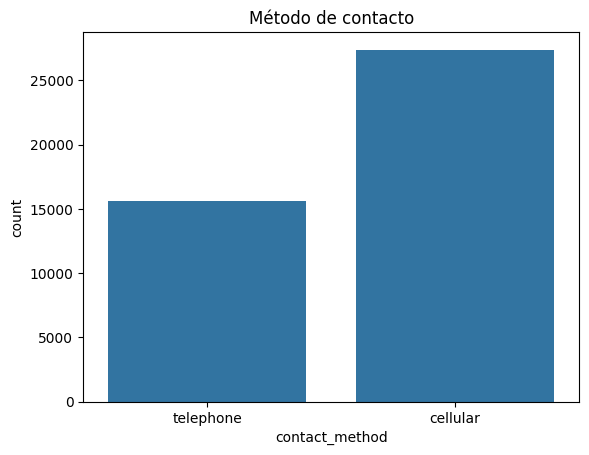

In [ ]:
sns.countplot(x='contact_method', data=datos_unidos_clientes)
plt.title('Método de contacto')
plt.show()

### **Año de contacto**

In [129]:
conteo_contact_year = datos_unidos_clientes['contact_year'].value_counts()
conteo_contact_year

contact_year
2019.0    8564
2017.0    8562
2018.0    8549
2015.0    8544
2016.0    8533
Name: count, dtype: int64

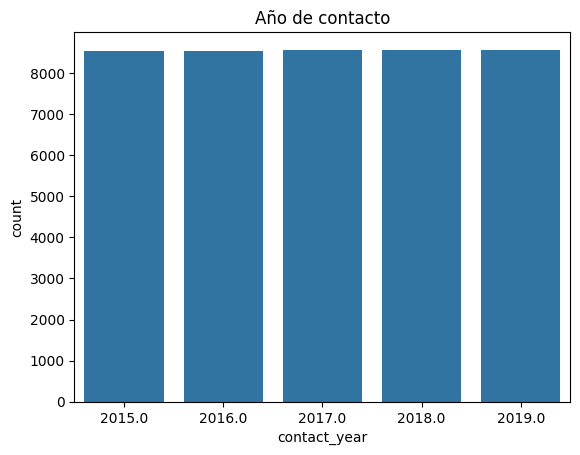

In [135]:
sns.countplot(x='contact_year', data=datos_unidos_clientes)
plt.title('Año de contacto')
plt.show()

### **Visitas mensuales a la web**

In [139]:
datos_unidos_clientes['monthly_web_visits'].unique()

array([29,  7,  5, 20, 26,  3, 21, 18,  9, 30, 32, 27, 15, 28,  2, 17, 12,
        1, 25, 10, 14, 24, 13, 11,  8, 23, 16,  4, 31, 19, 22,  6])

In [140]:
conteo_visitas_mensuales = datos_unidos_clientes['monthly_web_visits'].value_counts()
conteo_visitas_mensuales

monthly_web_visits
14    1424
32    1407
3     1406
12    1390
21    1382
31    1382
29    1381
23    1367
20    1360
27    1357
15    1357
13    1356
4     1356
28    1356
10    1355
22    1349
26    1342
25    1338
19    1334
24    1331
9     1330
17    1326
5     1325
30    1322
8     1322
6     1321
1     1308
11    1299
16    1290
18    1281
7     1277
2     1269
Name: count, dtype: int64

In [ ]:
#creamos categoria de visitas a la web

def cat_visitas_web(visitas):
    if  0 <visitas<=10:
        return '0-10'
    elif 11 <= visitas <= 20:
        return '11-20'
    elif 21 <= visitas <= 30:
        return '21-30'
    elif 31 <= visitas <= 40:
        return '31-40'
    elif 41 <= visitas <= 50:
        return '41-50'
    elif 51 <= visitas <= 60:
        return '51-60'
    elif visitas>=60:
        return '65+'
    else:
        return np.nan

In [144]:
datos_unidos_clientes['monthly_web_visits_cat'] = datos_unidos_clientes['monthly_web_visits'].apply(cat_visitas_web)
datos_unidos_clientes.sample(5)

,age,occupation,marital_status,education_level,credit_default,housing_loan,personal_loan,contact_method,last_contact_duration,campaign_contacts,days_since_last_contact,previous_contacts,previous_campaign_outcome,employment_variation_rate,consumer_price_index,consumer_confidence_index,euribor_3m_rate,number_of_employees,subscription_status,interaction_date,latitude,longitude,unique_id,contact_month_num,contact_month,contact_year,age_range_cat,call_range_cat,quarter_cat,semester_cat,annual_income_euros,kids_at_home,teens_at_home,enrollment_date,monthly_web_visits,enrollment_month_num,enrollment_year_num,monthly_web_visits_cat
18822,48,blue-collar,married,basic_4y,unknown,yes,no,cellular,69,2,999,0,nonexistent,1.4,93.444,-36.1,4.970000,5228.1,no,2019-04-01,35.354,-80.649,c029ca2f-64f5-4b2d-b697-7164d4913257,4.0,april,2019.0,45-54,1-5 min,2.0,1.0,138338,0,2,2012-11-02,23,11,2012,21-30
1837,33,services,married,high_school,no,yes,no,telephone,389,2,999,0,nonexistent,1.1,93.994,-36.4,4.855000,5191.0,no,2016-04-13,34.861,-68.211,5af60b5d-390f-40c0-9559-d6ec9245d419,4.0,april,2016.0,25-34,5-15 min,2.0,1.0,12369,2,0,2012-12-22,12,12,2012,11-20
35109,30,services,single,high_school,no,no,no,cellular,102,3,999,1,failure,-1.8,92.893,-46.2,3.616521,5099.1,no,2016-11-28,32.448,-89.712,b9ec172e-3174-4ded-9479-4185ba12deba,11.0,november,2016.0,25-34,1-5 min,4.0,2.0,44697,0,0,2014-04-09,4,4,2014,0-10
6820,39,admin,single,unknown,unknown,yes,no,telephone,177,1,999,0,nonexistent,1.1,93.994,-36.4,3.616521,5191.0,no,2017-06-22,42.250,-114.640,1b6584a3-1e82-401a-965b-d5e4d7a5cd48,6.0,june,2017.0,35-44,1-5 min,2.0,1.0,135913,1,1,2012-07-27,4,7,2012,0-10
270,39,housemaid,married,basic_9y,no,yes,no,telephone,935,3,999,0,nonexistent,1.1,93.994,-36.4,4.857000,5191.0,yes,2019-08-01,41.684,-114.471,f1d6ac6e-dcfb-4e32-96c6-2a77463f8a30,8.0,august,2019.0,35-44,15-30 min,3.0,2.0,176226,1,1,2012-09-18,5,9,2012,0-10


<Axes: xlabel='monthly_web_visits_cat', ylabel='count'>

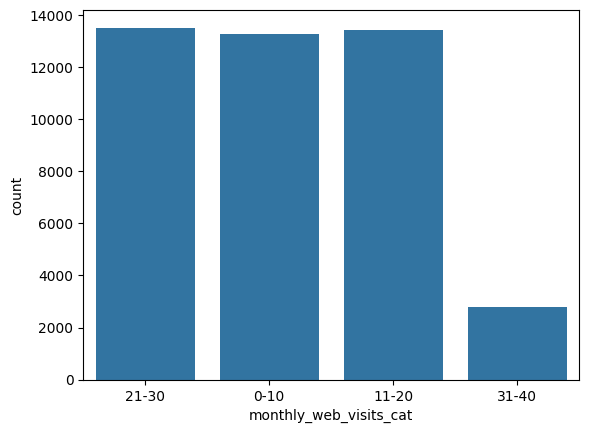

In [145]:
sns.countplot(data=datos_unidos_clientes,  x='monthly_web_visits_cat')